# Email Reply System — Exploratory Data Analysis

This notebook explores the raw email dataset: pair counts, text lengths, and sample pairs before training.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("..").resolve()
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "sample_emails.csv"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "email_pairs.csv"

df = pd.read_csv(RAW_PATH)
df.head()

Matplotlib is building the font cache; this may take a moment.


,incoming_email,reply
0,"Hi team, can we reschedule our meeting to Frid...","Sure, Friday at 2pm works for me. I'll update ..."
1,Please send me the Q3 sales report by end of day.,I'll have the Q3 sales report ready and sent t...
2,Are you available for a quick call this aftern...,"Yes, I'm free after 3pm. Feel free to call me ..."
3,Could you review the attached proposal and sha...,I'll review the proposal today and send you my...
4,Reminder: please submit your timesheet before ...,Thanks for the reminder. I'll submit my timesh...


In [2]:
print(f"Total pairs: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Missing values:\n{df.isnull().sum()}")

Total pairs: 5
Columns: ['incoming_email', 'reply']
Missing values:
incoming_email    0
reply             0
dtype: int64


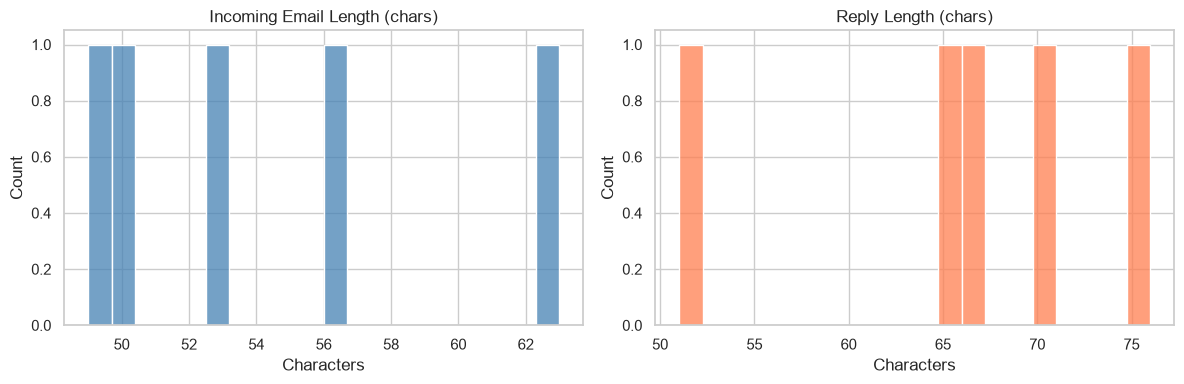

In [3]:
df["incoming_len"] = df["incoming_email"].str.len()
df["reply_len"] = df["reply"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["incoming_len"], bins=20, ax=axes[0], color="steelblue")
axes[0].set_title("Incoming Email Length (chars)")
axes[0].set_xlabel("Characters")

sns.histplot(df["reply_len"], bins=20, ax=axes[1], color="coral")
axes[1].set_title("Reply Length (chars)")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

In [4]:
df[["incoming_len", "reply_len"]].describe()

,incoming_len,reply_len
count,5.000000,5.0000
mean,54.200000,65.6000
std,5.630275,9.2358
min,49.000000,51.0000
25%,50.000000,65.0000
50%,53.000000,66.0000
75%,56.000000,70.0000
max,63.000000,76.0000


In [5]:
for i, row in df.head(3).iterrows():
    print(f"--- Pair {i + 1} ---")
    print(f"INCOMING: {row['incoming_email']}")
    print(f"REPLY:    {row['reply']}\n")

--- Pair 1 ---
INCOMING: Hi team, can we reschedule our meeting to Friday at 2pm?
REPLY:    Sure, Friday at 2pm works for me. I'll update the calendar invite.

--- Pair 2 ---
INCOMING: Please send me the Q3 sales report by end of day.
REPLY:    I'll have the Q3 sales report ready and sent to you by 5pm today.

--- Pair 3 ---
INCOMING: Are you available for a quick call this afternoon?
REPLY:    Yes, I'm free after 3pm. Feel free to call me then.



In [6]:
# Run preprocessing from notebook (optional)
import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data_preprocessing import preprocess

processed = preprocess(RAW_PATH, PROCESSED_PATH)
processed.head()

Saved 5 pairs to C:\Users\ADMIN\Desktop\EMAIL_ML_PROJECT\email_reply_system\data\processed\email_pairs.csv


,incoming_email,reply
0,"Hi team, can we reschedule our meeting to Frid...","Sure, Friday at 2pm works for me. I'll update ..."
1,Please send me the Q3 sales report by end of day.,I'll have the Q3 sales report ready and sent t...
2,Are you available for a quick call this aftern...,"Yes, I'm free after 3pm. Feel free to call me ..."
3,Could you review the attached proposal and sha...,I'll review the proposal today and send you my...
4,Reminder: please submit your timesheet before ...,Thanks for the reminder. I'll submit my timesh...
